Este script implementa una CNN con unidades SGCU (Sigmoid-Cosine) y pooling intermap
para clasificar firmas como genuinas (0) o falsificadas (1). El modelo se entrena
de forma writer-independent usando CEDAR (train+val) y KUDESIA (test). Incluye
preprocesamiento con SSMHED, recorte, y visualización Grad-CAM para interpretabilidad

In [1]:
!pip install opencv-contrib-python

IMPORTACIÓN DE LIBRERÍAS

In [3]:
import os
import shutil
import glob
import zipfile
import random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from random import sample
from google.colab import drive

 MONTAR DRIVE Y EXTRAER DATASETS (CEDAR y KUDESIA)

In [4]:
drive.mount('/content/drive')

ruta_cedar_zip = '/content/drive/MyDrive/CEDAR.zip'
ruta_kudesia_zip = '/content/drive/MyDrive/SIGNATURE.zip'

print("Descomprimiendo archivos...")
with zipfile.ZipFile(ruta_cedar_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/raw_cedar')
with zipfile.ZipFile(ruta_kudesia_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/raw_kudesia')

Mounted at /content/drive
Descomprimiendo archivos...


FUNCIÓN PARA APLANAR DIRECTORIOS (crea carpetas genuine/forged)

In [5]:
def aplanar_dataset(ruta_origen, dir_destino, etiqueta_gen, etiqueta_forg):
    dir_gen = os.path.join(dir_destino, 'genuine')
    dir_forg = os.path.join(dir_destino, 'forged')
    os.makedirs(dir_gen, exist_ok=True)
    os.makedirs(dir_forg, exist_ok=True)

    todas_imagenes = glob.glob(os.path.join(ruta_origen, '**', '*.*'), recursive=True)
    cont_gen, cont_forg = 0, 0

    for ruta in todas_imagenes:
        ruta_lower = ruta.lower()
        if not ruta_lower.endswith(('.png', '.jpg', '.jpeg')):
            continue

        if any(palabra in ruta_lower for palabra in etiqueta_forg):
            shutil.copy(ruta, os.path.join(dir_forg, os.path.basename(ruta)))
            cont_forg += 1
        elif any(palabra in ruta_lower for palabra in etiqueta_gen):
            shutil.copy(ruta, os.path.join(dir_gen, os.path.basename(ruta)))
            cont_gen += 1

    return cont_gen, cont_forg

APLANAR CEDAR (entrenamiento/validación) y KUDESIA (test)

In [6]:
print("\nAplanando CEDAR para Entrenamiento...")
gen_train, forg_train = aplanar_dataset(
    '/content/raw_cedar',
    '/content/dataset_train',
    etiqueta_gen=['org', 'orig'],
    etiqueta_forg=['forg']
)
print(f"CEDAR - Genuinas: {gen_train} | Falsas: {forg_train}")

print("\nAplanando KUDESIA para Test...")
gen_test, forg_test = aplanar_dataset(
    '/content/raw_kudesia',
    '/content/dataset_test',
    etiqueta_gen=['real'],
    etiqueta_forg=['fake']
)
print(f"KUDESIA - Genuinas: {gen_test} | Falsas: {forg_test}")


Aplanando CEDAR para Entrenamiento...
CEDAR - Genuinas: 1320 | Falsas: 1320

Aplanando KUDESIA para Test...
KUDESIA - Genuinas: 240 | Falsas: 240


CONFIGURACIÓN DEL DISPOSITIVO Y PARÁMETROS GLOBALES

In [7]:
cfg = {
    'device': 'cuda',
    'train': {'epochs': 40, 'lr': 0.0005, 'batch_size': 16, 'weight_decay': 1e-4}
}
device = torch.device(cfg['device'] if torch.cuda.is_available() else 'cpu')

FUNCIONES DE PREPROCESAMIENTO (CLAHE, mediana, SSMHED)

In [8]:
def st_clahe(gray, clip=2.0, tile=(8,8)):
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile)
    out = clahe.apply(gray)
    lap = cv2.Laplacian(gray, cv2.CV_32F)
    contrast = cv2.normalize(np.abs(lap), None, 0, 1.0, cv2.NORM_MINMAX)
    blend = (1.0 - contrast).astype(np.float32)
    blend = cv2.blur(blend, (15,15))
    return (out.astype(np.float32) * blend + gray.astype(np.float32) * (1-blend)).astype(np.uint8)

def median_denoise(gray, k=3):
    return cv2.medianBlur(gray, k)

# --- DETECTOR DE BORDES SSMHED ---
def sobel_gradients(img, ksize=3):
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=ksize)
    gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=ksize)
    mag = np.sqrt(gx*gx + gy*gy)
    return mag

def sparse_refine(mag, lam=0.8):
    m = mag.copy()
    if m.max() > 0: m = m / m.max()
    thr = np.mean(m) * lam
    m_ref = np.where(m > thr, m, m * 0.2)
    return cv2.GaussianBlur(m_ref, (3,3), 0)

def marr_hildreth_like(mag):
    g = cv2.GaussianBlur(mag, (5,5), 1.0)
    lap = cv2.Laplacian(g, cv2.CV_32F)
    lap = np.abs(lap)
    return lap / (lap.max() + 1e-9)

def ssmhed(img_gray, k=3, lam=0.8, threshold=0.15):
    mag = sobel_gradients(img_gray, k)
    mag_ref = sparse_refine(mag, lam)
    lap = marr_hildreth_like(mag_ref)
    comb = mag_ref + lap
    comb = comb / (comb.max()+1e-9)
    edges = (comb > threshold).astype('uint8')*255
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_close)

    try:
        edges = cv2.ximgproc.thinning(edges, thinningType=cv2.ximgproc.THINNING_ZHANGSUEN)
    except (AttributeError, cv2.error):
        kernel_open = np.ones((2, 2), np.uint8)
        edges = cv2.morphologyEx(edges, cv2.MORPH_OPEN, kernel_open)
    return edges

FUNCIÓN DEFINITIVA DE PREPROCESAMIENTO PARA SGCIP-CNN

In [9]:
def procesar_firma_definitiva(img_path):
    img_original = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_original is None: return np.zeros((32, 32), dtype=np.float32)

    img_rs = cv2.resize(img_original, (256, 256))
    pre = st_clahe(img_rs)
    pre_final = median_denoise(pre)

    esqueleto = ssmhed(pre_final, threshold=0.15)
    kernel_tijera = np.ones((5, 5), np.uint8)
    mascara_de_corte = cv2.dilate(esqueleto, kernel_tijera, iterations=1)

    firma_recortada = np.full_like(pre_final, 255)
    firma_recortada[mascara_de_corte > 0] = pre_final[mascara_de_corte > 0]

    final_input = cv2.resize(firma_recortada, (32, 32)).astype('float32') / 255.0
    return 1.0 - final_input  # fondo 0, trazo > 0

VISUALIZACIÓN DEL PREPROCESAMIENTO (muestra original, máscara y resultado)

Generando visualización...


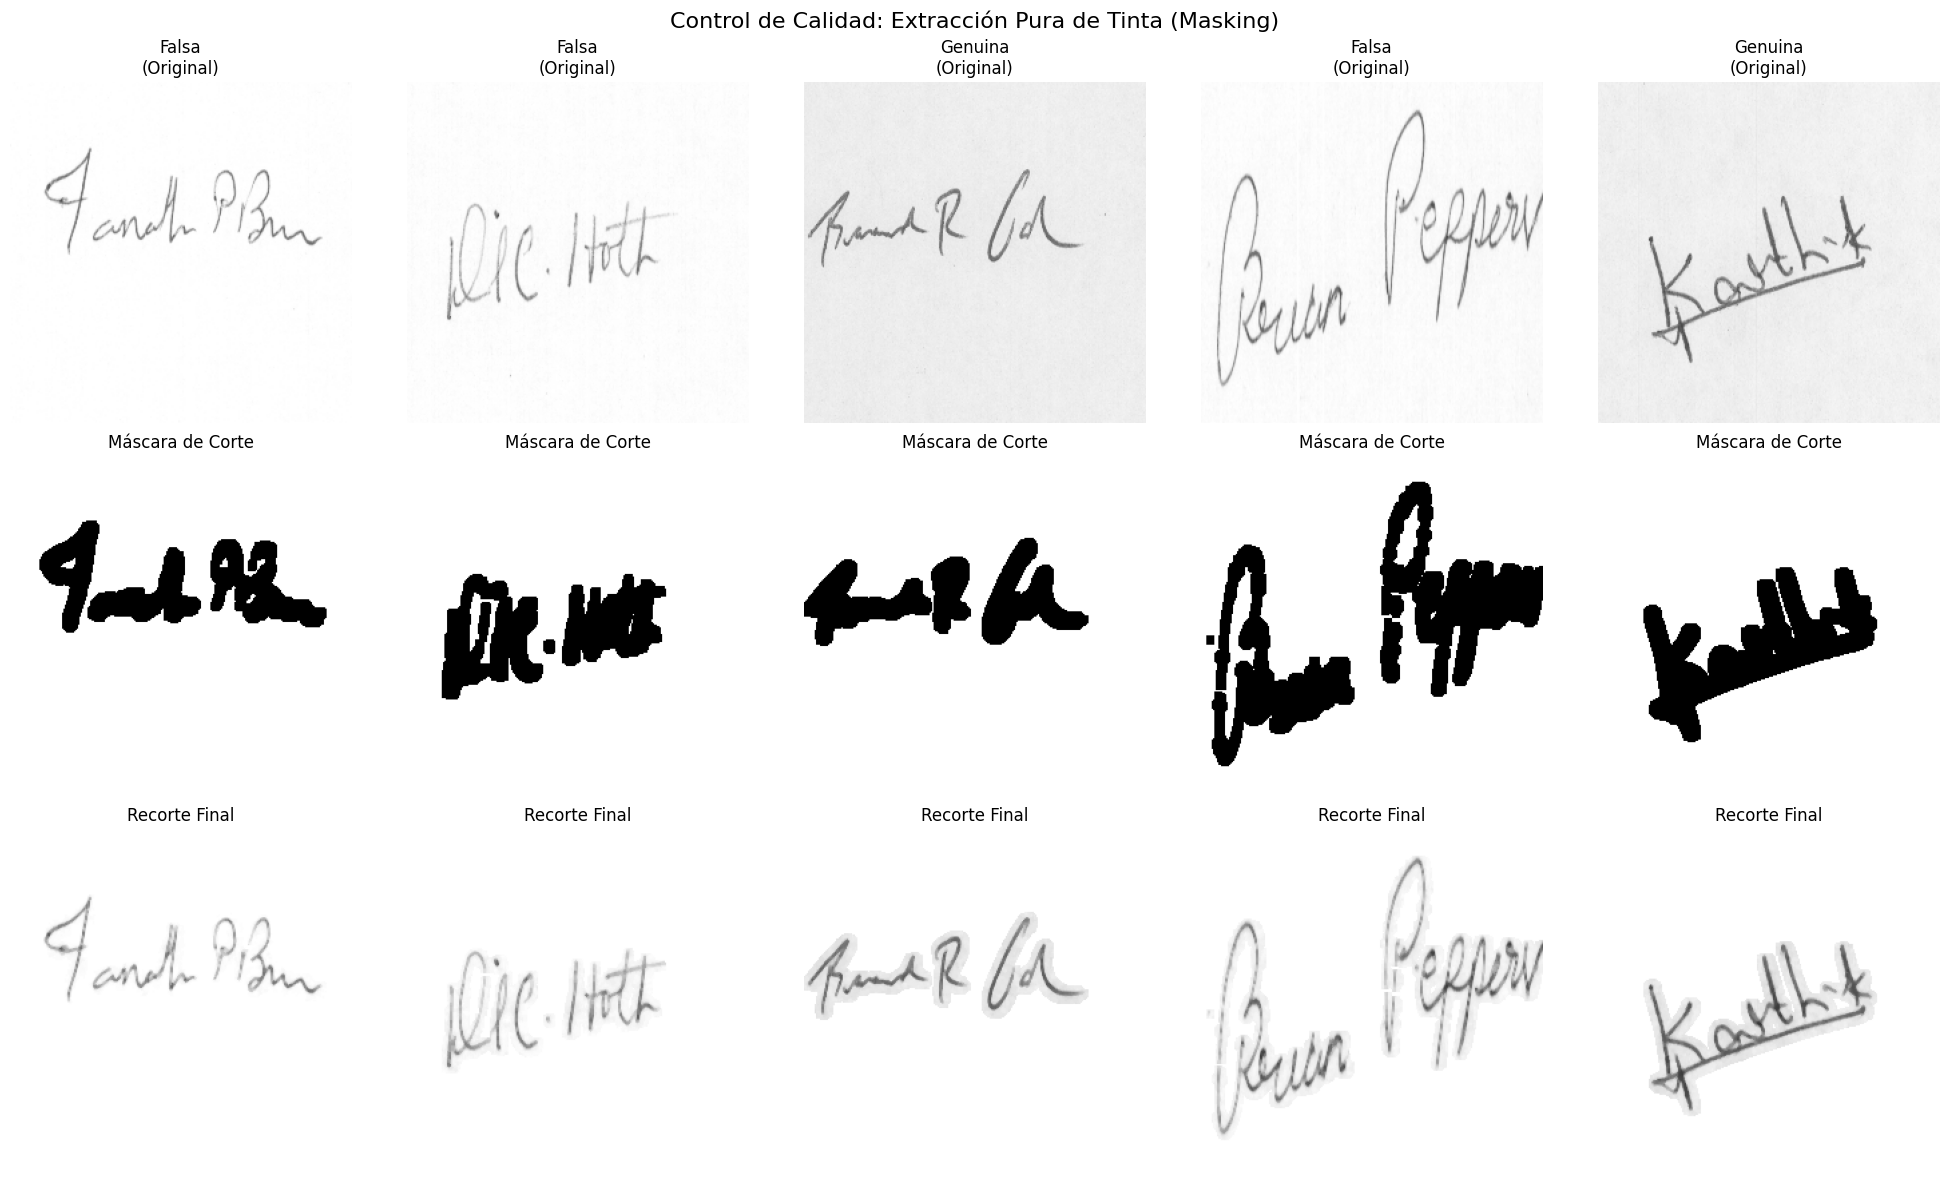

In [10]:
def visualizar_recorte_completo(paths_imagenes, num_muestras=5):
    if not paths_imagenes: return
    rutas_aleatorias = sample(paths_imagenes, min(num_muestras, len(paths_imagenes)))

    fig, axes = plt.subplots(3, num_muestras, figsize=(20, 12))
    fig.suptitle("Control de Calidad: Extracción Pura de Tinta (Masking)", fontsize=16)

    for i, path_img in enumerate(rutas_aleatorias):
        img_original = cv2.imread(path_img, cv2.IMREAD_GRAYSCALE)
        if img_original is None: continue
        img_rs = cv2.resize(img_original, (256, 256))

        pre = st_clahe(img_rs)
        pre_final = median_denoise(pre)

        esqueleto = ssmhed(pre_final, threshold=0.15)
        kernel_tijera = np.ones((5, 5), np.uint8)
        mascara_de_corte = cv2.dilate(esqueleto, kernel_tijera, iterations=1)

        firma_recortada = np.full_like(pre_final, 255)
        firma_recortada[mascara_de_corte > 0] = pre_final[mascara_de_corte > 0]

        es_forged = 'forged' in path_img.lower() or 'fake' in path_img.lower()
        clase_str = "Falsa" if es_forged else "Genuina"

        ax_orig = axes[0, i] if num_muestras > 1 else axes[0]
        ax_orig.imshow(img_rs, cmap='gray', vmin=0, vmax=255)
        ax_orig.set_title(f"{clase_str}\n(Original)")
        ax_orig.axis('off')

        ax_mask = axes[1, i] if num_muestras > 1 else axes[1]
        ax_mask.imshow(cv2.bitwise_not(mascara_de_corte), cmap='gray')
        ax_mask.set_title("Máscara de Corte")
        ax_mask.axis('off')

        ax_result = axes[2, i] if num_muestras > 1 else axes[2]
        ax_result.imshow(firma_recortada, cmap='gray', vmin=0, vmax=255)
        ax_result.set_title("Recorte Final")
        ax_result.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

todas_las_rutas = glob.glob('/content/dataset_train/**/*.png', recursive=True) + glob.glob('/content/dataset_test/**/*.png', recursive=True)
print("Generando visualización...")
visualizar_recorte_completo(todas_las_rutas, num_muestras=5)

PREPARACIÓN DE DATOS CON DIVISIÓN POR AUTOR (WRITER-INDEPENDENT)

In [11]:
import re
random.seed(42)

def obtener_rutas_y_etiquetas(dir_base):
    rutas_gen = [os.path.join(dir_base, 'genuine', f) for f in os.listdir(os.path.join(dir_base, 'genuine')) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    rutas_forg = [os.path.join(dir_base, 'forged', f) for f in os.listdir(os.path.join(dir_base, 'forged')) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    return rutas_gen, rutas_forg

def agrupar_por_autor(rutas_gen, rutas_forg, prefijo_dataset):
    autores = {}
    for ruta in rutas_gen:
        nombre = os.path.basename(ruta)
        match = re.search(r'\d+', nombre)
        id_autor = f"{prefijo_dataset}_{match.group()}" if match else f"{prefijo_dataset}_misc"
        if id_autor not in autores: autores[id_autor] = {'gen': [], 'forg': []}
        autores[id_autor]['gen'].append(ruta)
    for ruta in rutas_forg:
        nombre = os.path.basename(ruta)
        match = re.search(r'\d+', nombre)
        id_autor = f"{prefijo_dataset}_{match.group()}" if match else f"{prefijo_dataset}_misc"
        if id_autor not in autores: autores[id_autor] = {'gen': [], 'forg': []}
        autores[id_autor]['forg'].append(ruta)
    return autores

cedar_gen, cedar_forg = obtener_rutas_y_etiquetas('/content/dataset_train')
kudesia_gen, kudesia_forg = obtener_rutas_y_etiquetas('/content/dataset_test')

autores_cedar = agrupar_por_autor(cedar_gen, cedar_forg, "CEDAR")
autores_kudesia = agrupar_por_autor(kudesia_gen, kudesia_forg, "KUDESIA")

todos_los_autores = list(autores_cedar.items()) + list(autores_kudesia.items())
random.shuffle(todos_los_autores)

n_autores = len(todos_los_autores)
n_train = int(n_autores * 0.80)
n_val = int(n_autores * 0.10)

autores_train = todos_los_autores[:n_train]
autores_val = todos_los_autores[n_train:n_train+n_val]
autores_test = todos_los_autores[n_train+n_val:]

def desempaquetar_bloques(bloques_autores):
    lista_rutas, lista_etiq = [], []
    for id_autor, datos in bloques_autores:
        lista_rutas.extend(datos['gen'])
        lista_etiq.extend([0] * len(datos['gen']))
        lista_rutas.extend(datos['forg'])
        lista_etiq.extend([1] * len(datos['forg']))
    return lista_rutas, lista_etiq

listas_train, etiquetas_train = desempaquetar_bloques(autores_train)
listas_val, etiquetas_val = desempaquetar_bloques(autores_val)
listas_test, etiquetas_test = desempaquetar_bloques(autores_test)

DATA AUGMENTATION (rotación, traslación, escala)

In [13]:
transformada_entrenamiento = T.Compose([
    T.ToPILImage(),
    T.RandomRotation(degrees=12),
    T.RandomAffine(degrees=0, translate=(0.06, 0.06), scale=(0.9, 1.1)),
    T.ToTensor()
])

class ParticionSignatureDataset(Dataset):
    def __init__(self, lista_rutas, lista_etiquetas, es_entrenamiento=False):
        self.rutas = lista_rutas
        self.etiquetas = lista_etiquetas
        self.es_entrenamiento = es_entrenamiento

    def __len__(self): return len(self.rutas)

    def __getitem__(self, idx):
        procesada = procesar_firma_definitiva(self.rutas[idx])
        tensor_img = torch.from_numpy(procesada).unsqueeze(0)
        if self.es_entrenamiento:
            tensor_img = transformada_entrenamiento(tensor_img)
        return tensor_img, torch.tensor(self.etiquetas[idx], dtype=torch.long)

train_loader = DataLoader(ParticionSignatureDataset(listas_train, etiquetas_train, es_entrenamiento=True), batch_size=cfg['train']['batch_size'], shuffle=True)
val_loader = DataLoader(ParticionSignatureDataset(listas_val, etiquetas_val, es_entrenamiento=False), batch_size=cfg['train']['batch_size'], shuffle=False)
test_loader = DataLoader(ParticionSignatureDataset(listas_test, etiquetas_test, es_entrenamiento=False), batch_size=cfg['train']['batch_size'], shuffle=False)

print("="*50)
print("REPARTO ESTRICTO POR AUTOR (WRITER-INDEPENDENT) COMPLETADO")
print(f"Total de autores únicos: {n_autores}")
print(f"Autores en Entrenamiento: {len(autores_train)} -> {len(listas_train)} firmas")
print(f"Autores en Validación: {len(autores_val)} -> {len(listas_val)} firmas")
print(f"Autores en Test: {len(autores_test)} -> {len(listas_test)} firmas")
print("="*50)

REPARTO ESTRICTO POR AUTOR (WRITER-INDEPENDENT) COMPLETADO
Total de autores únicos: 103
Autores en Entrenamiento: 82 -> 2454 firmas
Autores en Validación: 10 -> 290 firmas
Autores en Test: 11 -> 376 firmas


DEFINICIÓN DE LA ARQUITECTURA SGCIP-CNN

In [14]:
class SGCU(nn.Module):
    def __init__(self):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(0.5))
        self.b = nn.Parameter(torch.tensor(0.5))
    def forward(self, x):
        return torch.sigmoid(self.a * x) * torch.cos(self.b * x)

class IntermapPool(nn.Module):
    def __init__(self, group_size=2):
        super().__init__()
        self.group_size = group_size
    def forward(self, x):
        B, C, H, W = x.shape
        g = self.group_size
        pad = (g - (C % g)) % g
        if pad != 0:
            x = F.pad(x, (0,0,0,0,0,pad))
            C = C + pad
        x = x.view(B, C//g, g, H, W)
        x, _ = torch.max(x, dim=2)
        return x

class SGCIP_CNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.sg = SGCU()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            IntermapPool(group_size=2),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            self.sg,
            nn.Dropout(0.4),
            nn.Linear(256, n_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

NTRENAMIENTO DEL MODELO

In [15]:
model = SGCIP_CNN(n_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=cfg['train']['lr'], weight_decay=cfg['train']['weight_decay'])

epochs = cfg['train']['epochs']
hist_train_loss, hist_val_loss = [], []
hist_train_acc, hist_val_acc = [], []

print("="*50)
print(" INICIANDO ENTRENAMIENTO Y RECOLECCIÓN DE MÉTRICAS")
print("="*50)

for epoch in range(epochs):
    model.train()
    train_loss, train_correct = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()

    epoch_train_loss = train_loss / len(listas_train)
    epoch_train_acc = train_correct / len(listas_train)

    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()

    epoch_val_loss = val_loss / len(listas_val)
    epoch_val_acc = val_correct / len(listas_val)

    hist_train_loss.append(epoch_train_loss)
    hist_val_loss.append(epoch_val_loss)
    hist_train_acc.append(epoch_train_acc)
    hist_val_acc.append(epoch_val_acc)

    print(f"Época [{epoch+1:02d}/{epochs}] -> Loss Train: {epoch_train_loss:.4f} | Loss Val: {epoch_val_loss:.4f} | Acc Val: {epoch_val_acc*100:.2f}%")

 INICIANDO ENTRENAMIENTO Y RECOLECCIÓN DE MÉTRICAS
Época [01/40] -> Loss Train: 0.4893 | Loss Val: 0.5312 | Acc Val: 67.59%
Época [02/40] -> Loss Train: 0.3441 | Loss Val: 0.6760 | Acc Val: 62.76%
Época [03/40] -> Loss Train: 0.3101 | Loss Val: 0.3875 | Acc Val: 78.62%
Época [04/40] -> Loss Train: 0.2653 | Loss Val: 0.2100 | Acc Val: 90.34%
Época [05/40] -> Loss Train: 0.2744 | Loss Val: 0.2569 | Acc Val: 87.24%
Época [06/40] -> Loss Train: 0.2696 | Loss Val: 0.3362 | Acc Val: 81.03%
Época [07/40] -> Loss Train: 0.2727 | Loss Val: 1.2514 | Acc Val: 53.79%
Época [08/40] -> Loss Train: 0.2834 | Loss Val: 0.2722 | Acc Val: 85.86%
Época [09/40] -> Loss Train: 0.2421 | Loss Val: 0.3219 | Acc Val: 84.14%
Época [10/40] -> Loss Train: 0.2410 | Loss Val: 0.6061 | Acc Val: 72.76%
Época [11/40] -> Loss Train: 0.2346 | Loss Val: 0.2039 | Acc Val: 90.00%
Época [12/40] -> Loss Train: 0.2488 | Loss Val: 0.3067 | Acc Val: 84.14%
Época [13/40] -> Loss Train: 0.2415 | Loss Val: 0.1802 | Acc Val: 89.66%


CURVAS DE APRENDIZAJE (Loss y Accuracy)

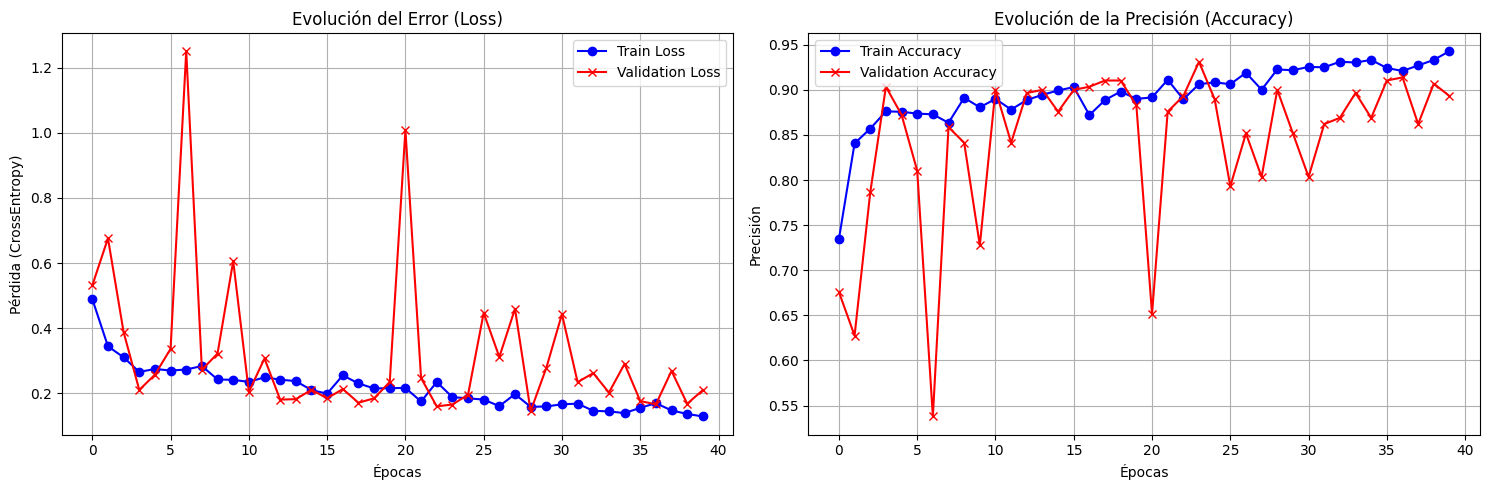

In [16]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_train_loss, label='Train Loss', color='blue', marker='o')
plt.plot(hist_val_loss, label='Validation Loss', color='red', marker='x')
plt.title('Evolución del Error (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (CrossEntropy)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(hist_train_acc, label='Train Accuracy', color='blue', marker='o')
plt.plot(hist_val_acc, label='Validation Accuracy', color='red', marker='x')
plt.title('Evolución de la Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

EVALUACIÓN EN TEST INDEPENDIENTE (MEZCLA CEDAR + KUDESIA) - MÉTRICAS COMPLETAS


 EVALUACIÓN EN TEST INDEPENDIENTE (MEZCLA CEDAR + KUDESIA)
>> ACCURACY GLOBAL EN TEST: 93.62% <<

--- Reporte de clasificación (Test) ---
              precision    recall  f1-score   support

 Genuine (0)     0.9184    0.9574    0.9375       188
  Forged (1)     0.9556    0.9149    0.9348       188

    accuracy                         0.9362       376
   macro avg     0.9370    0.9362    0.9361       376
weighted avg     0.9370    0.9362    0.9361       376


Métricas para GENUINAS (clase 0): Precision=0.9184, Recall=0.9574, F1=0.9375
Métricas para FALSIFICADAS (clase 1): Precision=0.9556, Recall=0.9149, F1=0.9348


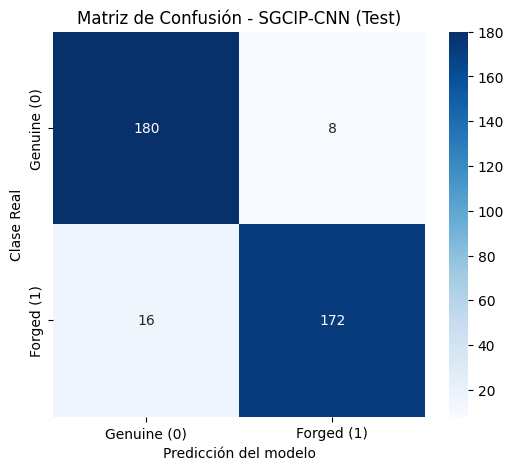

In [17]:
print("\n" + "="*50)
print(" EVALUACIÓN EN TEST INDEPENDIENTE (MEZCLA CEDAR + KUDESIA)")
print("="*50)

model.eval()
test_correct = 0
all_preds, all_labels = [], []
all_scores = []  # Probabilidad de clase "forged" (1)

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        test_correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_scores.extend(probs[:, 1].cpu().numpy())  # puntuación para clase 1 (falsa)

final_test_acc = test_correct / len(listas_test)
print(f">> ACCURACY GLOBAL EN TEST: {final_test_acc * 100:.2f}% <<")

# --- Reporte de clasificación detallado ---
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

print("\n--- Reporte de clasificación (Test) ---")
target_names = ['Genuine (0)', 'Forged (1)']
print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

# Métricas individuales
precision_0 = precision_score(all_labels, all_preds, pos_label=0)
recall_0    = recall_score(all_labels, all_preds, pos_label=0)
f1_0        = f1_score(all_labels, all_preds, pos_label=0)

precision_1 = precision_score(all_labels, all_preds, pos_label=1)
recall_1    = recall_score(all_labels, all_preds, pos_label=1)
f1_1        = f1_score(all_labels, all_preds, pos_label=1)

print(f"\nMétricas para GENUINAS (clase 0): Precision={precision_0:.4f}, Recall={recall_0:.4f}, F1={f1_0:.4f}")
print(f"Métricas para FALSIFICADAS (clase 1): Precision={precision_1:.4f}, Recall={recall_1:.4f}, F1={f1_1:.4f}")

# --- Matriz de confusión (mejorada) ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine (0)', 'Forged (1)'],
            yticklabels=['Genuine (0)', 'Forged (1)'])
plt.title('Matriz de Confusión - SGCIP-CNN (Test)')
plt.ylabel('Clase Real')
plt.xlabel('Predicción del modelo')
plt.show()

GUARDAR MODELO ENTRENADO

In [18]:
torch.save(model.state_dict(), 'modelo_sgcip_cnn_optimo.pth')
print("Modelo guardado como 'modelo_sgcip_cnn_optimo.pth'")

Modelo guardado como 'modelo_sgcip_cnn_optimo.pth'


GRAD-CAM (OPCIONAL)


 GENERANDO MAPAS DE CALOR (GRAD-CAM) - Modo interpretativo


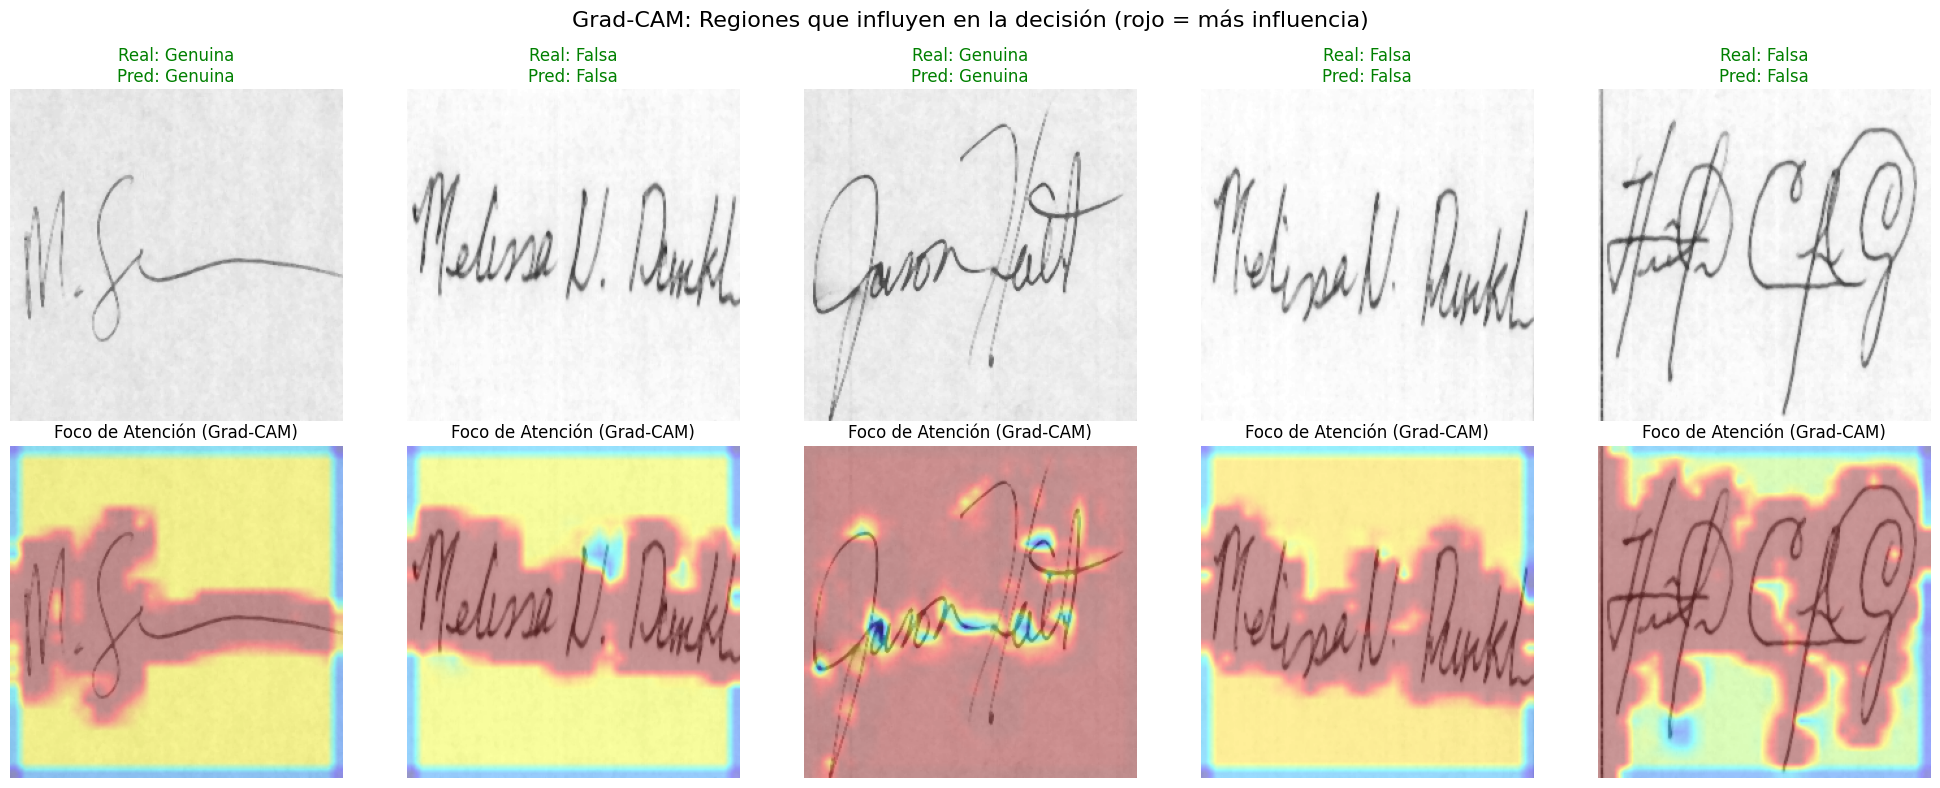

In [22]:
class SimpleGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x, class_idx):
        self.model.eval()
        output = self.model(x)
        self.model.zero_grad()
        target = output[0, class_idx]
        target.backward(retain_graph=True)

        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]

        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)
        return cam

print("\n" + "="*50)
print(" GENERANDO MAPAS DE CALOR (GRAD-CAM) - Modo interpretativo")
print("="*50)

target_layer = model.features[4]  # capa convolucional después de la segunda conv
cam_obj = SimpleGradCAM(model, target_layer)

dataset_test = test_loader.dataset
indices_aleatorios = random.sample(range(len(dataset_test)), 5)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Grad-CAM: Regiones que influyen en la decisión (rojo = más influencia)", fontsize=16)

for i, idx in enumerate(indices_aleatorios):
    img_tensor, label = dataset_test[idx]
    img_batch = img_tensor.unsqueeze(0).to(device)
    ruta_original = dataset_test.rutas[idx]

    output = model(img_batch)
    pred_class = output.argmax(dim=1).item()
    cam_crudo = cam_obj(img_batch, pred_class)

    # Recuperar imagen de alta resolución (256x256) para superposición
    img_alta_res = cv2.imread(ruta_original, cv2.IMREAD_GRAYSCALE)
    img_alta_res = cv2.resize(img_alta_res, (256, 256))
    pre = st_clahe(img_alta_res)
    pre_final = median_denoise(pre)
    img_rgb = cv2.cvtColor(pre_final, cv2.COLOR_GRAY2RGB)

    # Escalar CAM de 32x32 a 256x256
    cam_escalado = cv2.resize(cam_crudo, (256, 256))
    cam_escalado -= np.min(cam_escalado)
    if np.max(cam_escalado) != 0: cam_escalado /= np.max(cam_escalado)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam_escalado), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img_rgb, 0.6, heatmap, 0.4, 0)

    clase_real = "Falsa" if label.item() == 1 else "Genuina"
    clase_pred = "Falsa" if pred_class == 1 else "Genuina"
    color_titulo = 'green' if clase_real == clase_pred else 'red'

    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(f"Real: {clase_real}\nPred: {clase_pred}", color=color_titulo)
    axes[0, i].axis('off')

    axes[1, i].imshow(overlay)
    axes[1, i].set_title("Foco de Atención (Grad-CAM)")
    axes[1, i].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()